# MODELO BETO





In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

from src.procesamiento_corpus.preprocesamiento import cargar_y_preparar_corpus
from src.modelos_analisis_semantico.beto import (
    cargar_beto, embeddings_de_textos, embedding_de_palabra_en_contexto,
    analizar_polisemia, buscador_semantico, completar_mask, matriz_similitud_documentos,
    extraer_oraciones_con_palabra
)


## CARGA DEL CORPUS Y MODELO

In [3]:
corpus = cargar_y_preparar_corpus()
corpus[["lugar", "categoria", "calificacion", "comentarios_espanol"]].head()


,lugar,categoria,calificacion,comentarios_espanol
0,Playa Manuel Antonio,parque,5.0,La playa de Manuel Antonio es absolutamente im...
1,Playa Manuel Antonio,parque,5.0,Una de las dos playas que están separadas en e...
2,Playa Manuel Antonio,parque,5.0,Playa excepcional a la que sólo se puede acced...
3,Playa Manuel Antonio,parque,5.0,"Para cualquier turista o incluso local, MAB es..."
4,Playa Manuel Antonio,parque,4.0,"Bonita playa pero no la más bonita del país, h..."


In [4]:
cargar_beto()
print("BETO cargado correctamente.")


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 20402.43it/s]
[transformers] BertModel LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
pooler.dense.bias                          | MISSING    | 
pooler.dense.weight                        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpo

BETO cargado correctamente.


## POLISEMIA



In [5]:
ejemplo_pos = "El plato está muy rico, se nota el buen sazón."
ejemplo_neg = "El dueño del hotel es un señor muy rico y exclusivo."

v1 = embedding_de_palabra_en_contexto("rico", ejemplo_pos)
v2 = embedding_de_palabra_en_contexto("rico", ejemplo_neg)

if v1 is None or v2 is None:
    oracion_problema = ejemplo_pos if v1 is None else ejemplo_neg
    print(f"No se encontró la palabra 'rico' tokenizada tal cual en: '{oracion_problema}'")
else:
    from sklearn.metrics.pairwise import cosine_similarity
    print("Similitud coseno entre los dos usos de 'rico':", cosine_similarity([v1], [v2])[0][0])


Similitud coseno entre los dos usos de 'rico': 0.7224829


### ANÁLISIS DE POLISEMIA CON VARIAS ORACIONES




In [6]:
PALABRA_POLISEMICA = "rico"

"""
La palabra a buscar puede ser cambiada por otras
"""

oraciones_encontradas = extraer_oraciones_con_palabra(corpus, PALABRA_POLISEMICA, max_oraciones=5)
oraciones_rico_positivas = oraciones_encontradas["positiva"]
oraciones_rico_negativas = oraciones_encontradas["negativa"]

print(f"Oraciones POSITIVAS encontradas ({len(oraciones_rico_positivas)}):")
for o in oraciones_rico_positivas:
    print(f"  - {o}")

print(f"\nOraciones NEGATIVAS encontradas ({len(oraciones_rico_negativas)}):")
for o in oraciones_rico_negativas:
    print(f"  - {o}")

if len(oraciones_rico_positivas) < 2 or len(oraciones_rico_negativas) < 2:
    print(f"\nMuy pocos ejemplos reales para '{PALABRA_POLISEMICA}' en uno de los grupos -- "
          "probá otra palabra más frecuente en el corpus, o interpretá el resultado con cautela.")

resultado = analizar_polisemia(PALABRA_POLISEMICA, oraciones_rico_positivas, oraciones_rico_negativas)
print(f"\n{resultado}")


Oraciones POSITIVAS encontradas (5):
  - Un restaurante con decoración bonita, los platillos tiene un sabor muy rico y es una mezcla de recetas costarricenses con un giro Gourmet.
  - El buffet es rico y el personal es muy agradable y servicial en todo momento.
  - Pasé por un desayuno familiar, desde la entrada el ambiente es precioso, lejos de la ciudad, lejos de la chusma, se come rico.
  - Todo estuvo muy limpio, desayuno muy rico.
  - El personal muy amable y servicial en todo momento, es un hotel muy bonito con muchas amenidades, parece que estás dentro de un bosque es hermoso, habitación limpia, desayuno rico, está a 5 min del centro en coche Todo bien ninguna queja

Oraciones NEGATIVAS encontradas (1):
  - Muy caro para lo que es, un pinto normal común y corriente que ni rico estaba en 7000 colones, con lo que compro hasta dos y mucho mejores en otro lugares

Muy pocos ejemplos reales para 'rico' en uno de los grupos -- probá otra palabra más frecuente en el corpus, o interpret

## BÚSQUEDA SEMÁNTICA DE RESEÑAS

In [10]:
embeddings_corpus = embeddings_de_textos(corpus["comentarios_espanol"].tolist(), modo="mean", batch_size=100)
print(f"Embeddings del corpus: {embeddings_corpus.shape}")


  procesadas 100/2402 reseñas...
  procesadas 200/2402 reseñas...
  procesadas 300/2402 reseñas...
  procesadas 400/2402 reseñas...
  procesadas 500/2402 reseñas...
  procesadas 600/2402 reseñas...
  procesadas 700/2402 reseñas...
  procesadas 800/2402 reseñas...
  procesadas 900/2402 reseñas...
  procesadas 1000/2402 reseñas...
  procesadas 1100/2402 reseñas...
  procesadas 1200/2402 reseñas...
  procesadas 1300/2402 reseñas...
  procesadas 1400/2402 reseñas...
  procesadas 1500/2402 reseñas...
  procesadas 1600/2402 reseñas...
  procesadas 1700/2402 reseñas...
  procesadas 1800/2402 reseñas...
  procesadas 1900/2402 reseñas...
  procesadas 2000/2402 reseñas...
  procesadas 2100/2402 reseñas...
  procesadas 2200/2402 reseñas...
  procesadas 2300/2402 reseñas...
  procesadas 2400/2402 reseñas...
  procesadas 2402/2402 reseñas...
Embeddings del corpus: (2402, 768)


In [11]:
resultados_busqueda = buscador_semantico(
    "un lugar para descansar tranquilamente", # Ejemplo de oración a buscar
    corpus["comentarios_espanol"].tolist(),
    embeddings_corpus,
    top_n=5,
)
for r in resultados_busqueda:
    print(f"[{r['similitud']:.3f}] {r['reseña'][:150]}...")


  procesadas 1/1 reseñas...
[0.917] Un lugar acogedor, tranquilo y excelente para descansar...
[0.898] Un bonito lugar para refrescarse de la rutina y compartir con amigos o familia....
[0.896] Me encanto este lugar. Muy tranquilo y bonito para relajarte todo el día....
[0.894] Un lugar espectacular  con ganas de volver algún día...
[0.892] Es un hotel muy lindo con hermosos jardines y decoraciones para recorrer y desconectarse un rato. También tiene juegos para niños....


## MASKED LANGUAGE MODEL

In [13]:
print("'El servicio del hotel fue [MASK].' ->", completar_mask("El servicio del hotel fue [MASK]."))
print("'El sendero del parque estaba [MASK].' ->", completar_mask("El sendero del parque estaba [MASK]."))
print("'La comida del restaurante es [MASK].' ->", completar_mask("La comida del restaurante es [MASK]."))


Loading weights: 100%|██████████| 204/204 [00:00<00:00, 16827.37it/s]


'El servicio del hotel fue [MASK].' -> ['gratuito', 'cancelado', 'limitado', 'suspendido', 'interrumpido']
'El sendero del parque estaba [MASK].' -> ['bloqueado', 'roto', 'cerrado', 'abierto', 'abandonado']
'La comida del restaurante es [MASK].' -> ['[UNK]', 'tradicional', 'excelente', 'típica', 'deliciosa']


## HEATMAP



In [14]:
muestra = pd.concat([
    grupo.sample(min(5, len(grupo)), random_state=42)
    for _, grupo in corpus.groupby("categoria")
]).reset_index(drop=True)

print(f"Muestra: {len(muestra)} reseñas ({muestra['categoria'].value_counts().to_dict()})")


Muestra: 15 reseñas ({'alojamiento': 5, 'parque': 5, 'restaurante': 5})


  procesadas 15/15 reseñas...


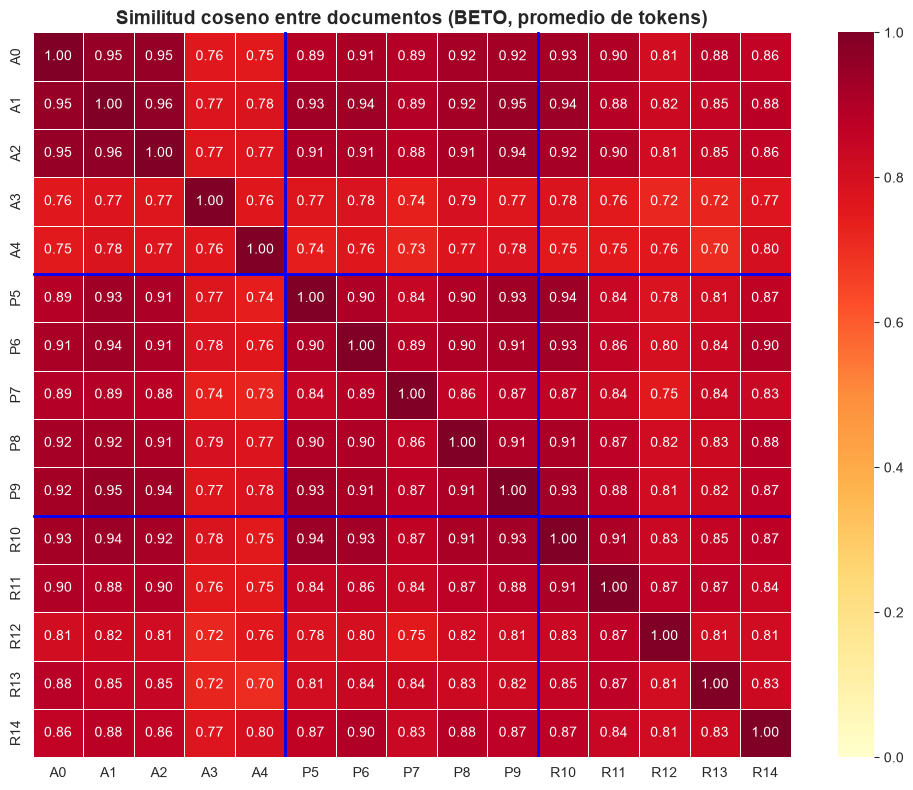

P=Parque, R=Restaurante, A=Alojamiento


In [16]:
embeddings_muestra = embeddings_de_textos(muestra["comentarios_espanol"].tolist(), modo="mean", batch_size=100)
sim_beto = matriz_similitud_documentos(embeddings_muestra)

etiquetas = [f"{cat[0].upper()}{i}" for i, cat in enumerate(muestra["categoria"])]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(sim_beto, annot=True, fmt=".2f", cmap="YlOrRd",
            xticklabels=etiquetas, yticklabels=etiquetas,
            vmin=0, vmax=1, linewidths=0.5, ax=ax)
ax.set_title("Similitud coseno entre documentos (BETO, promedio de tokens)", fontsize=14, fontweight="bold")

for pos in range(5, len(muestra), 5):
    ax.axhline(y=pos, color="blue", linewidth=2)
    ax.axvline(x=pos, color="blue", linewidth=2)

plt.tight_layout()
plt.show()

print("P=Parque, R=Restaurante, A=Alojamiento")


## RESULTADOS PRECALCULADOS PARA VISUALIZACIÓN

El dashboard (`visualizacion/modelos.py`) usa un enfoque híbrido: la
**búsqueda semántica es en vivo** (se calcula el embedding de la consulta
del usuario al momento), pero para no tener que re-procesar las 1,205
reseñas con BETO cada vez que arranca el servidor, **precalculamos y
guardamos**:
  - Los embeddings del corpus completo (para comparar contra la consulta en vivo)
  - Los resultados de polisemia y de Masked LM (se muestran fijos, no se recalculan)


In [17]:
import json
import numpy as np

np.save("../../data/processed/beto_embeddings_corpus.npy", embeddings_corpus)
print(f"Guardado: beto_embeddings_corpus.npy {embeddings_corpus.shape}")


Guardado: beto_embeddings_corpus.npy (2402, 768)


In [18]:

resultados_precalculados = {
    "polisemia": analizar_polisemia(
        "rico", oraciones_rico_positivas, oraciones_rico_negativas,
    ),
    "mlm_ejemplos": [
        {
            "oracion": "El servicio del hotel fue [MASK].",
            "predicciones": completar_mask("El servicio del hotel fue [MASK]."),
        },
        {
            "oracion": "El sendero del parque estaba [MASK].",
            "predicciones": completar_mask("El sendero del parque estaba [MASK]."),
        },
        {
            "oracion": "La comida del restaurante es [MASK].",
            "predicciones": completar_mask("La comida del restaurante es [MASK]."),
        },
    ],
}

with open("../../data/processed/beto_resultados_precalculados.json", "w", encoding="utf-8") as f:
    json.dump(resultados_precalculados, f, ensure_ascii=False, indent=2)

print("Guardado: beto_resultados_precalculados.json")
print(json.dumps(resultados_precalculados, ensure_ascii=False, indent=2))


Guardado: beto_resultados_precalculados.json
{
  "polisemia": {
    "palabra": "rico",
    "similitud_intra_positivas": 0.9249781966209412,
    "similitud_intra_negativas": 0.9238773584365845,
    "similitud_entre_positiva_negativa": 0.7503716945648193
  },
  "mlm_ejemplos": [
    {
      "oracion": "El servicio del hotel fue [MASK].",
      "predicciones": [
        "gratuito",
        "cancelado",
        "limitado",
        "suspendido",
        "interrumpido"
      ]
    },
    {
      "oracion": "El sendero del parque estaba [MASK].",
      "predicciones": [
        "bloqueado",
        "roto",
        "cerrado",
        "abierto",
        "abandonado"
      ]
    },
    {
      "oracion": "La comida del restaurante es [MASK].",
      "predicciones": [
        "[UNK]",
        "tradicional",
        "excelente",
        "típica",
        "deliciosa"
      ]
    }
  ]
}


### EMBEDINGS DEL CORPUS


Se agregan los embedings en una columna nueva al corpus con todas las reseñas

In [19]:
corpus = pd.read_csv("../../data/processed/corpus_final.csv")

In [20]:
textos = corpus["comentarios_espanol"].fillna("").tolist()
embeddings_corpus = embeddings_de_textos(textos, modo="mean", batch_size=100)
print(f"Embeddings calculados: {embeddings_corpus.shape}")


  procesadas 100/2402 reseñas...
  procesadas 200/2402 reseñas...
  procesadas 300/2402 reseñas...
  procesadas 400/2402 reseñas...
  procesadas 500/2402 reseñas...
  procesadas 600/2402 reseñas...
  procesadas 700/2402 reseñas...
  procesadas 800/2402 reseñas...
  procesadas 900/2402 reseñas...
  procesadas 1000/2402 reseñas...
  procesadas 1100/2402 reseñas...
  procesadas 1200/2402 reseñas...
  procesadas 1300/2402 reseñas...
  procesadas 1400/2402 reseñas...
  procesadas 1500/2402 reseñas...
  procesadas 1600/2402 reseñas...
  procesadas 1700/2402 reseñas...
  procesadas 1800/2402 reseñas...
  procesadas 1900/2402 reseñas...
  procesadas 2000/2402 reseñas...
  procesadas 2100/2402 reseñas...
  procesadas 2200/2402 reseñas...
  procesadas 2300/2402 reseñas...
  procesadas 2400/2402 reseñas...
  procesadas 2402/2402 reseñas...
Embeddings calculados: (2402, 768)


In [21]:
corpus["embeddings_beto"] = [json.dumps(vector.tolist()) for vector in embeddings_corpus]
corpus.head(2)

,lugar,texto,calificacion,categoria,fuente,idioma_comentario,comentarios_espanol,emojis,penntreebank,universalpos,embeddings_beto
0,Playa Manuel Antonio,Manuel Antonio Beach is absolutely stunning. T...,5.0,parque,google_maps,en,La playa de Manuel Antonio es absolutamente im...,NaN,"[('La', 'NNP'), ('playa', 'FW'), ('de', 'FW'),...","[('La', 'DET', 'el'), ('playa', 'NOUN', 'playa...","[-0.2211126685142517, 0.30410563945770264, -0...."
1,Playa Manuel Antonio,Una de las dos playas que están separadas en e...,5.0,parque,google_maps,es,Una de las dos playas que están separadas en e...,😊,"[('Una', 'NNP'), ('de', 'FW'), ('las', 'FW'), ...","[('Una', 'PRON', 'uno'), ('de', 'ADP', 'de'), ...","[0.00788198597729206, 0.11182807385921478, -0...."


In [22]:
corpus.to_csv("../../data/processed/corpus.csv", index=False)
print(f"Guardado en: {"../../data/processed/corpus.csv"}")

Guardado en: ../../data/processed/corpus.csv
